# Phase 5: Buyer/Seller Analysis — Table 2 & Figures 4–5

**Buyer** holds a solar farm: daily revenue proportional to GHI.
**Hedge**: buy N_c SoRad put contracts per day (strike K_n = ATM, price V0_n from Phase 3).

Cash flows:
$$\text{CF}_u(R_n) = E_f \cdot N_p \cdot R_n \cdot \bar{E}$$
$$\text{CF}_h(R_n) = \text{CF}_u(R_n) + N_c \cdot [\max(K_n - R_n, 0) \cdot \text{tick} - V_{0,n} \cdot \text{tick}]$$

Optimal $N_c$ minimises $\sum_n (\text{CF}_h - \text{CF}_b(K_n))^2$ — closed-form quadratic solution.

Parameters: $E_f=0.15$, $N_p=10\,000$, $\bar{E}=0.08$, tick$=0.10$ €/kWh/m².

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from solarrpy.buyer import (
    compute_buyer_table, unhedged_cf, benchmark_cf, hedged_cf,
    optimal_Nc, mape, E_f, N_p, E_bar, tick,
)
from solarrpy.sorad import daily_strike, sorad_price
from solarrpy.calibration import calibrate_window

## 0. Load data

In [2]:
df = pd.read_csv('../data/Bologna.csv', parse_dates=['date'])
print(f'Full dataset: {len(df)} rows, years {df["Year"].min()}–{df["Year"].max()}')
print(f'Buyer params: E_f={E_f}, N_p={N_p}, E_bar={E_bar}, tick={tick}')

Full dataset: 7465 rows, years 2005–2025
Buyer params: E_f=0.15, N_p=10000, E_bar=0.08, tick=0.1


## 1. Run train-test loop (2014–2023) → Table 2

In [3]:
print('Running buyer train-test loop 2014–2023...')
table2 = compute_buyer_table(
    df,
    eval_years=list(range(2014, 2024)),
    coords={'lat': 44.5},
    progress=True,
)
print('\nDone.')

Running buyer train-test loop 2014–2023...
  [2014] Training 2005–2013... 

buyer 2014... 

N_c=433.1  MAPE_u=32.83%  MAPE_h=27.92%  seller=17861.19€
  [2015] Training 2005–2014... 

buyer 2015... 

N_c=483.9  MAPE_u=33.56%  MAPE_h=26.69%  seller=22485.36€
  [2016] Training 2005–2015... 

...

N_c=453.1  MAPE_u=31.95%  MAPE_h=25.58%  seller=20905.64€
  [2022] Training 2005–2021... 

buyer 2022... 

N_c=523.0  MAPE_u=32.03%  MAPE_h=24.39%  seller=25882.64€
  [2023] Training 2005–2022... 

buyer 2023... 

N_c=508.1  MAPE_u=33.63%  MAPE_h=26.25%  seller=23139.02€

Done.


## 2. Table 2

In [4]:
print('Table 2: Buyer/Seller Analysis (Bologna SoRadIDX, 2014–2023)')
print('=' * 80)
display_cols = ['eval_year', 'N_c_opt', 'unhedged_MAPE', 'hedged_MAPE', 'seller_net_eur']
print(table2[display_cols].to_string(index=False, float_format='{:.3f}'.format))

print(f'\nHedged MAPE < Unhedged MAPE: {(table2["hedged_MAPE"] < table2["unhedged_MAPE"]).sum()}/10 years')
print(f'Mean unhedged MAPE: {table2["unhedged_MAPE"].mean():.2f}%')
print(f'Mean hedged   MAPE: {table2["hedged_MAPE"].mean():.2f}%')
print(f'Mean seller net:    {table2["seller_net_eur"].mean():.2f} €/year')

table2.to_csv('../results/Table2_Buyer.csv', index=False, float_format='%.6f')
print('\nSaved to results/Table2_Buyer.csv')

Table 2: Buyer/Seller Analysis (Bologna SoRadIDX, 2014–2023)
 eval_year  N_c_opt  unhedged_MAPE  hedged_MAPE  seller_net_eur
      2014  433.080         32.834       27.915       17861.194
      2015  483.859         33.565       26.688       22485.361
      2016  430.318         34.781       29.356       18713.102
      2017  486.584         33.697       25.664       24523.659
      2018  401.701         32.865       27.497       17702.007
      2019  540.434         34.600       27.319       24285.199
      2020  488.345         33.634       26.189       23991.088
      2021  453.140         31.953       25.578       20905.641
      2022  522.981         32.030       24.387       25882.640
      2023  508.099         33.628       26.250       23139.020

Hedged MAPE < Unhedged MAPE: 10/10 years
Mean unhedged MAPE: 33.36%
Mean hedged   MAPE: 26.68%
Mean seller net:    21948.89 €/year

Saved to results/Table2_Buyer.csv


## 3. Figure 4: SoRadIDX prices + MAPE (combined)

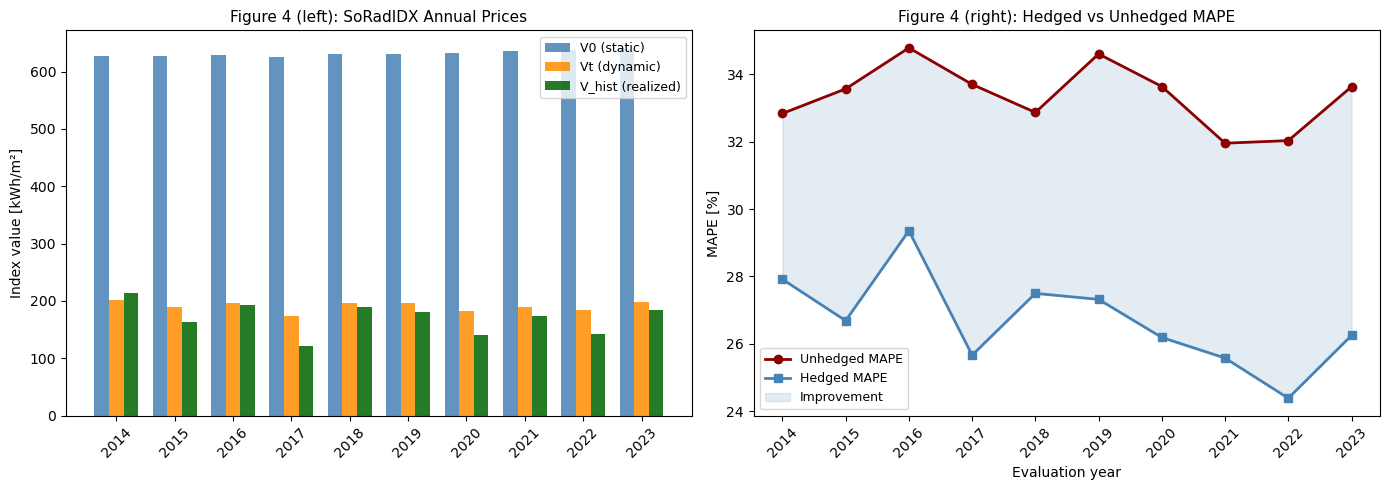

Saved Figure4_combined.png


In [5]:
# Load Phase 4 Table 1 for V0/Vt/V_hist comparison
table1 = pd.read_csv('../results/Table1_SoRadIDX.csv')
table1 = table1.merge(table2[['eval_year','unhedged_MAPE','hedged_MAPE']], on='eval_year')

years = table1['eval_year'].values
x = np.arange(len(years))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: SoRadIDX values
ax = axes[0]
ax.bar(x - w, table1['V0'],     width=w, label='V0 (static)',      color='steelblue', alpha=0.85)
ax.bar(x,     table1['Vt'],     width=w, label='Vt (dynamic)',     color='darkorange', alpha=0.85)
ax.bar(x + w, table1['V_hist'], width=w, label='V_hist (realized)',color='darkgreen',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('Index value [kWh/m²]')
ax.set_title('Figure 4 (left): SoRadIDX Annual Prices', fontsize=11)
ax.legend(fontsize=9)

# Right panel: MAPE comparison
ax = axes[1]
ax.plot(years, table1['unhedged_MAPE'], 'o-', color='darkred',   lw=2, label='Unhedged MAPE')
ax.plot(years, table1['hedged_MAPE'],   's-', color='steelblue', lw=2, label='Hedged MAPE')
ax.fill_between(years, table1['hedged_MAPE'], table1['unhedged_MAPE'],
                alpha=0.15, color='steelblue', label='Improvement')
ax.set_xlabel('Evaluation year')
ax.set_ylabel('MAPE [%]')
ax.set_title('Figure 4 (right): Hedged vs Unhedged MAPE', fontsize=11)
ax.legend(fontsize=9)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.savefig('../results/Figure4_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_combined.png')

## 4. Figure 5: Cash-flow detail for one year (2014)

In [6]:
# Recompute 2014 per-day data for Figure 5
print('Computing per-day detail for 2014...')

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train, target_col='GHI', clearsky_col='clearsky',
    date_col='date', coords={'lat': 44.5}, train_end_year=2013,
)

# Conditioning: Dec 31 2013
t0_row = df[df['Year'] == 2013].sort_values('date').iloc[-1]
R_t0, t0 = float(t0_row['GHI']), t0_row['date']

df_2014 = df[df['Year'] == 2014].sort_values('date').reset_index(drop=True)
K_arr  = np.array([daily_strike(r['date'], cal) for _, r in df_2014.iterrows()])
V0_arr = np.array([sorad_price(K_arr[i], R_t0, str(t0.date()), str(r['date'].date()), cal)
                   for i, (_, r) in enumerate(df_2014.iterrows())])
R_arr  = df_2014['GHI'].values

N_c_2014 = float(table2.loc[table2['eval_year'] == 2014, 'N_c_opt'].iloc[0])

cf_u = unhedged_cf(R_arr)
cf_b = benchmark_cf(K_arr)
cf_h = hedged_cf(R_arr, K_arr, V0_arr, N_c_2014)

dates = df_2014['date']
print(f'N_c_opt (2014) = {N_c_2014:.1f} contracts')

Computing per-day detail for 2014...


N_c_opt (2014) = 433.1 contracts


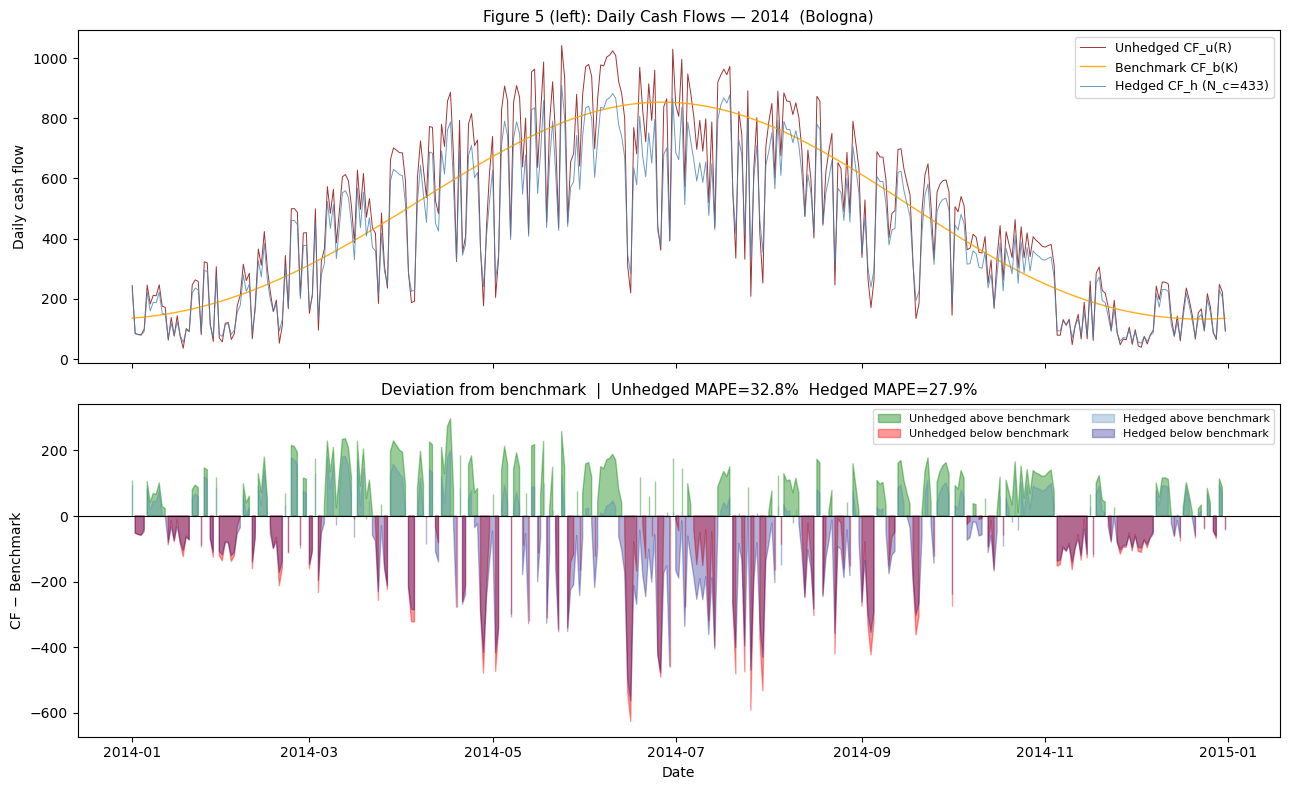

Saved Figure5_cashflows_2014.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(dates, cf_u, lw=0.7, color='darkred',   alpha=0.8, label='Unhedged CF_u(R)')
ax.plot(dates, cf_b, lw=1.0, color='orange',    alpha=0.9, label='Benchmark CF_b(K)')
ax.plot(dates, cf_h, lw=0.7, color='steelblue', alpha=0.8, label=f'Hedged CF_h (N_c={N_c_2014:.0f})')
ax.set_ylabel('Daily cash flow')
ax.set_title('Figure 5 (left): Daily Cash Flows — 2014  (Bologna)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
ax.fill_between(dates, cf_u - cf_b, 0,
                where=(cf_u >= cf_b), alpha=0.4, color='green',  label='Unhedged above benchmark')
ax.fill_between(dates, cf_u - cf_b, 0,
                where=(cf_u < cf_b),  alpha=0.4, color='red',    label='Unhedged below benchmark')
ax.fill_between(dates, cf_h - cf_b, 0,
                where=(cf_h >= cf_b), alpha=0.3, color='steelblue', label='Hedged above benchmark')
ax.fill_between(dates, cf_h - cf_b, 0,
                where=(cf_h < cf_b),  alpha=0.3, color='navy',      label='Hedged below benchmark')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('CF − Benchmark')
ax.set_xlabel('Date')
ax.set_title(f'Deviation from benchmark  |  '
             f'Unhedged MAPE={mape(cf_u,cf_b):.1f}%  '
             f'Hedged MAPE={mape(cf_h,cf_b):.1f}%', fontsize=11)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
plt.savefig('../results/Figure5_cashflows_2014.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure5_cashflows_2014.png')

## 5. Figure 5 (right): Seller net return per year

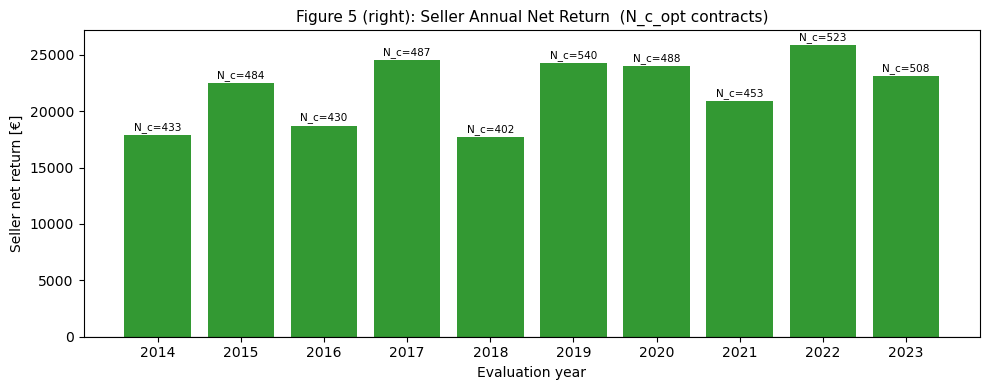

Saved Figure5_seller_net.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['green' if v >= 0 else 'red' for v in table2['seller_net_eur']]
ax.bar(table2['eval_year'], table2['seller_net_eur'], color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Evaluation year')
ax.set_ylabel('Seller net return [€]')
ax.set_title('Figure 5 (right): Seller Annual Net Return  (N_c_opt contracts)', fontsize=11)
ax.set_xticks(table2['eval_year'])

# Annotate N_c
for _, row in table2.iterrows():
    ax.text(row['eval_year'], row['seller_net_eur'] + 200,
            f'N_c={row["N_c_opt"]:.0f}', ha='center', va='bottom', fontsize=7.5)

fig.tight_layout()
plt.savefig('../results/Figure5_seller_net.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure5_seller_net.png')

## 6. Phase 5 gate checks

In [9]:
# Gate 1: Table 2 has 10 rows
assert len(table2) == 10, f'Expected 10 rows, got {len(table2)}'
print('GATE PASS: Table 2 has 10 rows (2014–2023)')

# Gate 2: N_c_opt >= 0 (no short selling)
assert (table2['N_c_opt'] >= 0).all(), 'Negative N_c found'
print('GATE PASS: All N_c_opt >= 0')

# Gate 3: hedged MAPE < unhedged MAPE for majority of years
n_better = (table2['hedged_MAPE'] < table2['unhedged_MAPE']).sum()
assert n_better >= 5, f'Hedged MAPE not better in majority of years: {n_better}/10'
print(f'GATE PASS: Hedged MAPE < Unhedged MAPE in {n_better}/10 years')

# Gate 4: All MAPE values finite and positive
assert table2['unhedged_MAPE'].gt(0).all() and np.isfinite(table2['unhedged_MAPE']).all()
assert table2['hedged_MAPE'].gt(0).all()   and np.isfinite(table2['hedged_MAPE']).all()
print('GATE PASS: All MAPE values positive and finite')

# Gate 5: Seller net return — print distribution
n_profit = (table2['seller_net_eur'] > 0).sum()
print(f'Seller profitable in {n_profit}/10 years')

print()
print('Phase 5 complete.')
print(f'  Mean unhedged MAPE: {table2["unhedged_MAPE"].mean():.2f}%')
print(f'  Mean hedged   MAPE: {table2["hedged_MAPE"].mean():.2f}%')
print(f'  MAPE reduction:     {(table2["unhedged_MAPE"] - table2["hedged_MAPE"]).mean():.2f}pp')
print(f'  Mean N_c_opt:       {table2["N_c_opt"].mean():.1f} contracts')
print(f'  Mean seller net:    {table2["seller_net_eur"].mean():.2f} €/year')

GATE PASS: Table 2 has 10 rows (2014–2023)
GATE PASS: All N_c_opt >= 0
GATE PASS: Hedged MAPE < Unhedged MAPE in 10/10 years
GATE PASS: All MAPE values positive and finite
Seller profitable in 10/10 years

Phase 5 complete.
  Mean unhedged MAPE: 33.36%
  Mean hedged   MAPE: 26.68%
  MAPE reduction:     6.67pp
  Mean N_c_opt:       474.9 contracts
  Mean seller net:    21948.89 €/year
